# Machine Learning Foundation

## Course 2, Part b: Regression Setup, Train-test Split LAB 


## Introduction

We will be working with a data set based on [housing prices in Ames, Iowa](https://www.kaggle.com/c/house-prices-advanced-regression-techniques). It was compiled for educational use to be a modernized and expanded alternative to the well-known Boston Housing dataset. This version of the data set has had some missing values filled for convenience.

There are an extensive number of features, so they've been described in the table below.

### Predictor

* SalePrice: The property's sale price in dollars. 

### Features

* MoSold: Month Sold
* YrSold: Year Sold   
* SaleType: Type of sale
* SaleCondition: Condition of sale
* MSSubClass: The building class
* MSZoning: The general zoning classification
* ...


## Import the necessary libraries


In [19]:
#!pip install pandas
#!pip install numpy
#!pip install matplotlib
#!pip install scikit-learn
#!pip install seaborn

In [1]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

## Question 1

* Import the data using Pandas and examine the shape. There are 79 feature columns plus the predictor, the sale price (`SalePrice`). 
* There are three different types: integers (`int64`), floats (`float64`), and strings (`object`, categoricals). Examine how many there are of each data type. 


In [2]:
import pandas as pd
import numpy as np

# Import the data using the file path
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/data/Ames_Housing_Sales.csv")
data.head()


print(data.shape)

(1379, 80)


In [3]:
data.dtypes.value_counts()

object     43
float64    21
int64      16
Name: count, dtype: int64

## Question 2

A significant challenge, particularly when dealing with data that have many columns, is ensuring each column gets encoded correctly. 

This is particularly true with data columns that are ordered categoricals (ordinals) vs unordered categoricals. Unordered categoricals should be one-hot encoded, however this can significantly increase the number of features and creates features that are highly correlated with each other.

Determine how many total features would be present, relative to what currently exists, if all string (object) features are one-hot encoded. Recall that the total number of one-hot encoded columns is `n-1`, where `n` is the number of categories.

一个主要挑战，尤其是在处理具有许多列的数据时，是确保每一列都被正确编码。

这一点在处理有序类别（ordinal）与无序类别（categorical）时尤为重要。无序类别应使用独热编码（one-hot encoding），但这会显著增加特征的数量，并引入彼此高度相关的特征。

请判断：如果将所有字符串（object）类型的特征都进行独热编码，最终会有多少个总特征？请注意，独热编码生成的列数为 n-1，其中 n 是该类别变量的唯一取值数量（类别数）。



In [4]:
# Select the object (string) columns
mask = data.dtypes == object
categorical_cols = data.columns[mask]

In [5]:
mask

1stFlrSF        False
2ndFlrSF        False
3SsnPorch       False
Alley            True
BedroomAbvGr    False
                ...  
WoodDeckSF      False
YearBuilt       False
YearRemodAdd    False
YrSold          False
SalePrice       False
Length: 80, dtype: bool

In [6]:
categorical_cols

Index(['Alley', 'BldgType', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'BsmtQual', 'CentralAir', 'Condition1', 'Condition2',
       'Electrical', 'ExterCond', 'ExterQual', 'Exterior1st', 'Exterior2nd',
       'Fence', 'FireplaceQu', 'Foundation', 'Functional', 'GarageCond',
       'GarageFinish', 'GarageQual', 'GarageType', 'Heating', 'HeatingQC',
       'HouseStyle', 'KitchenQual', 'LandContour', 'LandSlope', 'LotConfig',
       'LotShape', 'MSZoning', 'MasVnrType', 'MiscFeature', 'Neighborhood',
       'PavedDrive', 'PoolQC', 'RoofMatl', 'RoofStyle', 'SaleCondition',
       'SaleType', 'Street', 'Utilities'],
      dtype='object')

In [7]:
# Determine how many extra columns would be created
num_ohc_cols = (data[categorical_cols]
                .apply(lambda x: x.nunique())
                .sort_values(ascending=False))

#这一步是统计每个类别变量有多少个唯一取值（即类别数）。

#categorical_cols 是一个列表，包含所有需要进行 one-hot 编码的字符串列（也叫类别变量列）。
#x.nunique() 统计每列的唯一值数量。
#.sort_values(ascending=False) 是将这些列按照类别数从多到少排序，方便观察。
#变量 num_ohc_cols 存储了每个类别变量的类别数量。
num_ohc_cols 

Neighborhood     25
Exterior2nd      16
Exterior1st      14
Condition1        9
SaleType          9
Condition2        8
RoofMatl          8
HouseStyle        8
Functional        7
Heating           6
BsmtFinType2      6
RoofStyle         6
GarageType        6
Foundation        6
SaleCondition     6
LotConfig         5
MSZoning          5
HeatingQC         5
BldgType          5
GarageQual        5
GarageCond        5
FireplaceQu       5
BsmtFinType1      5
Electrical        5
BsmtExposure      4
MiscFeature       4
BsmtQual          4
LotShape          4
LandContour       4
KitchenQual       4
ExterCond         4
ExterQual         4
Fence             4
LandSlope         3
MasVnrType        3
PavedDrive        3
PoolQC            3
BsmtCond          3
GarageFinish      3
Street            2
Alley             2
CentralAir        2
Utilities         2
dtype: int64

In [8]:
# No need to encode if there is only one value
small_num_ohc_cols = num_ohc_cols.loc[num_ohc_cols>1]
#如果某个列只有一个取值，那它没有信息量，不需要编码。
#所以这里只保留那些具有两个或以上类别的列（即 nunique > 1），并赋值给 small_num_ohc_cols。
# Number of one-hot columns is one less than the number of categories
small_num_ohc_cols -= 1
#对于 one-hot 编码，每个变量生成的列数为 n - 1（因为可以省略一个类别作为参考项，防止多重共线性）。其他类别都标了1，最后一个就不用标了，都知道了
#所以对每列的类别数减一，得到真正会新增的列数。

# This is 215 columns, assuming the original ones are dropped. 
# This is quite a few extra columns!
small_num_ohc_cols.sum()
#将上一步得到的每列新增的编码列数求和，就是最终 one-hot 编码后，将要增加的总列数。
#例如结果为 215，意味着如果原始的字符串列被移除，将会新增 215 个 one-hot 编码后的列，这在特征维度上是显著增加的。

204

## Question 3

Let's create a new data set where all of the above categorical features will be one-hot encoded. We can fit this data and see how it affects the results.

* Used the dataframe `.copy()` method to create a completely separate copy of the dataframe for one-hot encoding
* On this new dataframe, one-hot encode each of the appropriate columns and add it back to the dataframe. Be sure to drop the original column.
* For the data that are not one-hot encoded, drop the columns that are string categoricals.

For the first step, numerically encoding the string categoricals, either Scikit-learn's `LabelEncoder` or `DictVectorizer` can be used. However, the former is probably easier since it doesn't require specifying a numerical value for each category, and we are going to one-hot encode all of the numerical values anyway. (Can you think of a time when `DictVectorizer` might be preferred?)

我们要创建一个新的数据集，把所有类别变量（categorical features）都进行 one-hot 编码，并观察编码对结果的影响。

步骤：
复制原始 DataFrame：

使用 .copy() 来创建原始数据的副本，避免原地修改。
在新副本中，对每个类别变量进行 one-hot 编码：

使用 pd.get_dummies()。
编码后将新列加回去，同时删除原始字符串列。
对于不进行 one-hot 编码的数据（即原始 DataFrame），只需把字符串类别列（object）删除即可。

In [9]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
import pandas as pd

# 复制原始数据，避免修改原始 DataFrame
data_ohc = data.copy()

# 初始化编码器：LabelEncoder 负责将字符串类别编码为整数，OneHotEncoder 负责将整数编码为独热向量
le = LabelEncoder()
ohc = OneHotEncoder()

# 遍历每一个需要 one-hot 编码的类别列（这些列已经被筛选出来，且唯一值数大于1）
for col in num_ohc_cols.index:
    
    # 使用 LabelEncoder 将字符串类别编码为整数（例如：['red', 'green', 'blue'] -> [2, 1, 0]）
    dat = le.fit_transform(data_ohc[col]).astype(int)
    
    # 删除原始的字符串列，稍后我们会添加独热编码后的新列
    data_ohc = data_ohc.drop(col, axis=1)

    # 使用 OneHotEncoder 将整数编码为独热向量（稀疏矩阵形式）
    # 注意要将 dat reshape 成二维列向量，否则会报错
    new_dat = ohc.fit_transform(dat.reshape(-1, 1))

    # 为新生成的 one-hot 列创建唯一的列名，例如 'color_0', 'color_1', ...
    n_cols = new_dat.shape[1]
    col_names = ['_'.join([col, str(x)]) for x in range(n_cols)]

    # 将稀疏矩阵转换为稠密矩阵，再构建一个新的 DataFrame，同时保留原索引
    new_df = pd.DataFrame(new_dat.toarray(), 
                          index=data_ohc.index, 
                          columns=col_names)

    # 将新的 one-hot 编码列添加回主 DataFrame
    data_ohc = pd.concat([data_ohc, new_df], axis=1)


In [10]:
# Column difference is as calculated above
data_ohc.shape[1] - data.shape[1]

215

In [11]:
print(data.shape[1])

# Remove the string columns from the dataframe
data = data.drop(num_ohc_cols.index, axis=1)

print(data.shape[1])

80
37


## Question 4

* Create train and test splits of both data sets. To ensure the data gets split the same way, use the same `random_state` in each of the two splits.
* For each data set, fit a basic linear regression model on the training data. 
* Calculate the mean squared error on both the train and test sets for the respective models. Which model produces smaller error on the test data and why?


In [12]:
from sklearn.model_selection import train_test_split

y_col = 'SalePrice'

# Split the data that is not one-hot encoded
feature_cols = [x for x in data.columns if x != y_col]
X_data = data[feature_cols]
y_data = data[y_col]

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, 
                                                    test_size=0.3, random_state=42)
# Split the data that is one-hot encoded
feature_cols = [x for x in data_ohc.columns if x != y_col]
X_data_ohc = data_ohc[feature_cols]
y_data_ohc = data_ohc[y_col]

X_train_ohc, X_test_ohc, y_train_ohc, y_test_ohc = train_test_split(X_data_ohc, y_data_ohc, 
                                                    test_size=0.3, random_state=42)

In [13]:
# Compare the indices to ensure they are identical
(X_train_ohc.index == X_train.index).all()

True

In [14]:
X_train

,1stFlrSF,2ndFlrSF,3SsnPorch,BedroomAbvGr,BsmtFinSF1,BsmtFinSF2,BsmtFullBath,BsmtHalfBath,BsmtUnfSF,EnclosedPorch,...,OverallCond,OverallQual,PoolArea,ScreenPorch,TotRmsAbvGrd,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,YrSold
461,630.0,0.0,0.0,1,515.0,0.0,1,0,115.0,0.0,...,8,4,0.0,0.0,3,630.0,0.0,1970,2002,2009
976,845.0,0.0,0.0,3,0.0,0.0,0,0,0.0,0.0,...,3,4,0.0,0.0,5,0.0,186.0,1957,1957,2009
1128,728.0,728.0,0.0,3,0.0,0.0,0,0,728.0,0.0,...,5,6,0.0,0.0,8,728.0,100.0,2005,2005,2008
904,561.0,668.0,0.0,2,285.0,0.0,0,0,276.0,0.0,...,6,6,0.0,0.0,5,561.0,150.0,1980,1980,2009
506,1601.0,0.0,0.0,3,1358.0,0.0,1,0,223.0,0.0,...,5,8,0.0,0.0,6,1581.0,180.0,2001,2002,2010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,855.0,601.0,0.0,3,311.0,0.0,0,0,544.0,0.0,...,5,6,0.0,0.0,7,855.0,26.0,1978,1978,2010
1130,815.0,875.0,0.0,3,0.0,0.0,0,0,815.0,330.0,...,6,7,0.0,0.0,7,815.0,0.0,1916,1950,2006
1294,1661.0,0.0,0.0,3,831.0,0.0,1,0,161.0,0.0,...,6,6,0.0,178.0,8,992.0,0.0,1955,1996,2008
860,742.0,742.0,0.0,3,0.0,0.0,0,0,742.0,0.0,...,5,6,0.0,0.0,8,742.0,36.0,2005,2005,2009


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

LR = LinearRegression()

# Storage for error values
error_df = list()

# Data that have not been one-hot encoded
LR = LR.fit(X_train, y_train)
y_train_pred = LR.predict(X_train)
y_test_pred = LR.predict(X_test)

error_df.append(pd.Series({'train': mean_squared_error(y_train, y_train_pred),
                           'test' : mean_squared_error(y_test,  y_test_pred)},
                           name='no enc'))

# Data that have been one-hot encoded
LR = LR.fit(X_train_ohc, y_train_ohc)
y_train_ohc_pred = LR.predict(X_train_ohc)
y_test_ohc_pred = LR.predict(X_test_ohc)

error_df.append(pd.Series({'train': mean_squared_error(y_train_ohc, y_train_ohc_pred),
                           'test' : mean_squared_error(y_test_ohc,  y_test_ohc_pred)},
                          name='one-hot enc'))

# Assemble the results
error_df = pd.concat(error_df, axis=1)
error_df

,no enc,one-hot enc
train,1.131507e+09,3.177267e+08
test,1.372182e+09,8.065328e+09


Note that the error values on the one-hot encoded data are very different for the train and test data. In particular, the errors on the test data are much higher. Based on the lecture, this is because the one-hot encoded model is overfitting the data. We will learn how to deal with issues like this in the next lesson.
以下是关于你提到的**过拟合问题**的中文解释和原因：

---

### 过拟合问题的解释：

在机器学习中，**过拟合**发生在模型在训练数据上表现得很好，但在测试数据上表现较差的情况。你提到的**one-hot 编码模型的误差在训练和测试数据之间差异较大，尤其是在测试数据上误差较高**，正是典型的过拟合现象。

#### 过拟合的原因：
1. **高维数据：**
   - One-hot 编码会将类别变量转换为高维稀疏矩阵。例如，假设某个类别变量有 1000 个不同的类别，那么编码后会生成 1000 个新特征。这会使得特征空间变得非常大，可能导致模型变得非常复杂，捕捉到数据中的噪声而非有效模式。

2. **模型复杂度：**
   - 高维特征会让模型变得更加复杂。如果模型过于复杂，它会非常拟合训练集中的每个细节，包括噪声和异常值，从而导致在新的、未见过的数据（如测试集）上表现不佳。

3. **训练集与测试集的分布差异：**
   - 如果训练集和测试集的类别分布不一致，one-hot 编码会造成严重问题。训练集中的某些类别可能在测试集上从未出现过，导致模型在测试集上的性能大幅下降。

---

### 如何应对过拟合问题：

你提到会在下一节课学习如何解决这个问题，常见的解决方法包括：

1. **正则化（Regularization）：**
   - 通过添加惩罚项来限制模型复杂度，防止模型过度拟合。例如，L1/L2 正则化。

2. **减少特征数量：**
   - 对于高维数据，可以通过降维技术（如 PCA）来减少特征数量，或者使用特征选择方法来保留最重要的特征。

3. **增加数据量：**
   - 通过收集更多的训练数据，可以帮助模型更好地泛化，减少过拟合。

4. **交叉验证：**
   - 使用交叉验证来评估模型的泛化能力，避免依赖于单一的训练集和测试集分配。

5. **提前停止（Early Stopping）：**
   - 在训练过程中，当验证集的误差不再下降时提前停止训练，防止模型在训练集上过拟合。

6. **使用集成方法：**
   - 像随机森林、梯度提升树等集成方法可以减少过拟合，因为它们通过多个模型的平均来进行预测。

---

理解这些过拟合的原因和解决方法将有助于你在接下来的课程中应对类似的问题。如果你有更多具体的代码问题或想要进一步探讨这些方法，随时告诉我！


## Question 5

For each of the data sets (one-hot encoded and not encoded):

* Scale the all the non-hot encoded values using one of the following: `StandardScaler`, `MinMaxScaler`, `MaxAbsScaler`.
* Compare the error calculated on the test sets

Be sure to calculate the skew (to decide if a transformation should be done) and fit the scaler on *ONLY* the training data, but then apply it to both the train and test data identically.
问题要求你对两个数据集（一个是已经进行 one-hot 编码，另一个是未编码的）进行缩放操作，并比较在测试集上的误差。

步骤如下：

📊 1. 数据缩放：
我们将对所有非 one-hot 编码的数据（通常是数值型特征）应用缩放。常用的缩放方法包括：

StandardScaler：标准化，处理数据使其均值为 0，标准差为 1。

MinMaxScaler：将数据缩放到指定范围，通常是 [0, 1]。

MaxAbsScaler：将数据缩放到 [-1, 1] 范围，但不会影响稀疏矩阵的结构。

📐 2. 计算偏度（Skew）：
为了确定是否需要对数据进行转换，首先需要计算数值数据的偏度（skew）。如果数据的偏度较大（如大于 1 或小于 -1），则可能需要进行转换（例如对数转换）来使其更加接近正态分布。

⚖️ 3. 数据缩放的顺序：
仅使用训练集数据来拟合缩放器。这保证了测试集数据不会在训练过程中泄露。

然后将训练集和测试集都应用相同的缩放器。

🧑‍💻 4. 误差计算：
最后，我们将在缩放后的数据上训练模型，并计算在测试集上的误差。这将帮助我们比较在缩放操作后模型的表现如何。

In [16]:
# Mute the setting wtih a copy warnings
pd.options.mode.chained_assignment = None

In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler


scalers = {'standard': StandardScaler(),
           'minmax': MinMaxScaler(),
           'maxabs': MaxAbsScaler()}

training_test_sets = {
    'not_encoded': (X_train, y_train, X_test, y_test),
    'one_hot_encoded': (X_train_ohc, y_train_ohc, X_test_ohc, y_test_ohc)}


# Get the list of float columns, and the float data
# so that we don't scale something we already scaled. 
# We're supposed to scale the original data each time
mask = X_train.dtypes == float
float_columns = X_train.columns[mask]

# initialize model
LR = LinearRegression()

# iterate over all possible combinations and get the errors
errors = {}
for encoding_label, (_X_train, _y_train, _X_test, _y_test) in training_test_sets.items():
    for scaler_label, scaler in scalers.items():
        trainingset = _X_train.copy()  # copy because we dont want to scale this more than once.
        testset = _X_test.copy()
        trainingset[float_columns] = scaler.fit_transform(trainingset[float_columns])
        testset[float_columns] = scaler.transform(testset[float_columns])
        LR.fit(trainingset, _y_train)
        predictions = LR.predict(testset)
        key = encoding_label + ' - ' + scaler_label + 'scaling'
        errors[key] = mean_squared_error(_y_test, predictions)

errors = pd.Series(errors)
print(errors.to_string())
print('-' * 80)
for key, error_val in errors.items():
    print(key, error_val)

not_encoded - standardscaling        1.372182e+09
not_encoded - minmaxscaling          1.372182e+09
not_encoded - maxabsscaling          1.372182e+09
one_hot_encoded - standardscaling    8.065328e+09
one_hot_encoded - minmaxscaling      8.065328e+09
one_hot_encoded - maxabsscaling      8.065328e+09
--------------------------------------------------------------------------------
not_encoded - standardscaling 1372182358.934502
not_encoded - minmaxscaling 1372182358.9345508
not_encoded - maxabsscaling 1372182358.9344902
one_hot_encoded - standardscaling 8065327607.247159
one_hot_encoded - minmaxscaling 8065327607.267794
one_hot_encoded - maxabsscaling 8065327607.290664


结论：Scaling 方式不影响误差

## Question 6

Plot predictions vs actual for one of the models.


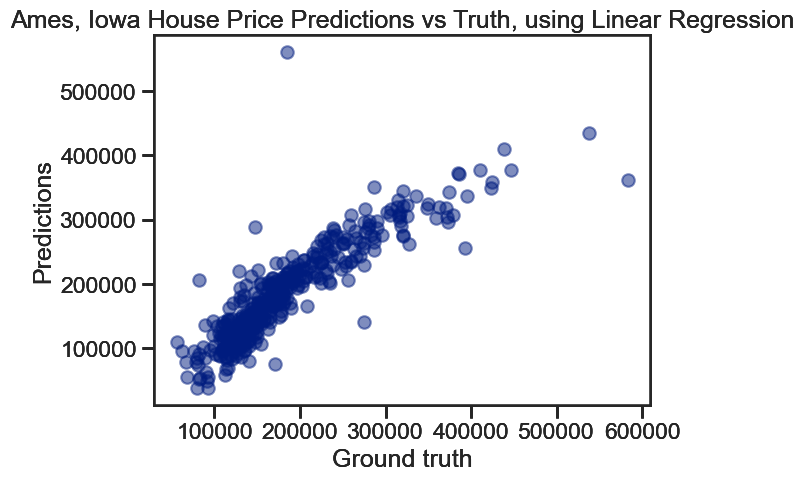

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('dark')

ax = plt.axes()
# we are going to use y_test, y_test_pred
ax.scatter(y_test, y_test_pred, alpha=.5)

ax.set(xlabel='Ground truth', 
       ylabel='Predictions',
       title='Ames, Iowa House Price Predictions vs Truth, using Linear Regression');

plt.show()

---
### Machine Learning Foundation (C) 2020 IBM Corporation
